In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt

sys.path.append('../')
from src.utils import load_smd_machine, sliding_window_transform, split_time_series, add_window_features

warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

pd. set_option('display.max_columns', None)
pd. set_option('display.max_rows', None)

### loading data

In [ ]:
base_path = '../ServerMachineDataset' 
machine_name = 'machine-1-1' # all manipulations are made on machine 1

df = load_smd_machine(base_path, machine_name)

In [3]:
print(f"{df.shape}")
print(f"Total incidents: {df['is_incident'].sum()}")

(28479, 39)
Total incidents: 2694


### transforming data with sliding window approach

In [4]:
X, y = sliding_window_transform(df)

(28439, 1140)
(28439,)
Incidents to predict: 2766


### spliting data into train/val/test sets

In [5]:
X_train, y_train, X_val, y_val, X_test, y_test = split_time_series(X, y)

In [6]:
print(f"Train set: {X_train.shape[0]} rows | Incidents: {int(y_train.sum())}")
print(f"Validation set: {X_val.shape[0]} rows | Incidents: {int(y_val.sum())}")
print(f"Test set: {X_test.shape[0]} rows | Incidents: {int(y_test.sum())}")
    

Train set: 19907 rows | Incidents: 2164
Validation set: 4266 rows | Incidents: 568
Test set: 4266 rows | Incidents: 34


### training baseline models (xgboost and random forest)

In [7]:
def train_models(X_train, y_train, X_val, y_val):
    # class_weight='balanced' automatically adjusts weights inversely proportional to class frequencies
    rf_model = RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )
    rf_model.fit(X_train, y_train)
    
    # Calculate scale_pos_weight to handle the class imbalance
    neg_cases = len(y_train) - y_train.sum()
    pos_cases = y_train.sum()
    scale_weight = neg_cases / pos_cases
    
    xgb_model = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_weight,
        eval_metric='aucpr',
        early_stopping_rounds=20,
        random_state=42
    )
    
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    return rf_model, xgb_model

In [8]:
rf_baseline_model, xgb_baseline_model = train_models(X_train, y_train, X_val, y_val)

### evaluating for the baseline

In [9]:
def evaluate_alerting_model(model, X_eval, y_eval, model_name="", target_recall=0.80, predefined_threshold=None):
    print(f"--- Evaluating {model_name} ---")
    y_probs = model.predict_proba(X_eval)[:, 1]
    
    if predefined_threshold is None:
        _, recalls, thresholds = precision_recall_curve(y_eval, y_probs)
        optimal_idx = np.where(recalls[:-1] >= target_recall)[0][-1] 
        threshold_to_use = thresholds[optimal_idx]
        print(f"Target Recall ~{target_recall*100}% -> Calculated Threshold: {threshold_to_use:.4f}")
    else:
        threshold_to_use = predefined_threshold
        print(f"Using Predefined Threshold: {threshold_to_use:.4f}")
    
    y_pred_custom = (y_probs >= threshold_to_use).astype(int)
    
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred_custom, target_names=['Normal (0)', 'Incident (1)']))
    
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred_custom).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    print("Confusion Matrix Details:")
    print(f"True Positives (Alerts): {tp}")
    print(f"False Negatives (Misses): {fn}")
    print(f"True Negatives (Quiet): {tn}")
    print(f"False Positives (False Alarms): {fp}")
    print(f"False Positive Rate (FPR): {fpr:.4f} ({fpr*100:.2f}%)\n")
    
    return threshold_to_use

**Here, we evaluate both models on the raw, flattened 30-minute windows. Because a standard 0.5 probability threshold is poorly suited for rare anomalies, we dynamically find the exact threshold required to hit the project's ~80% recall target. Both models perform reasonably well here, with XGBoost showing a slight edge in False Positive Rate (16.25% vs. Random Forest's 17.17%)**

In [10]:
xgb_baseline_threshold = evaluate_alerting_model(xgb_baseline_model, X_val, y_val, "XGBoost", target_recall=0.80)

--- Evaluating XGBoost ---
Target Recall ~80.0% -> Calculated Threshold: 0.4275

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.97      0.84      0.90      3698
Incident (1)       0.43      0.81      0.56       568

    accuracy                           0.83      4266
   macro avg       0.70      0.82      0.73      4266
weighted avg       0.90      0.83      0.85      4266

Confusion Matrix Details:
True Positives (Alerts): 459
False Negatives (Misses): 109
True Negatives (Quiet): 3097
False Positives (False Alarms): 601
False Positive Rate (FPR): 0.1625 (16.25%)



In [11]:
rf_baseline_threshold = evaluate_alerting_model(rf_baseline_model, X_val, y_val, "Random Forest", target_recall=0.80)

--- Evaluating Random Forest ---
Target Recall ~80.0% -> Calculated Threshold: 0.1304

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.96      0.83      0.89      3698
Incident (1)       0.42      0.80      0.55       568

    accuracy                           0.82      4266
   macro avg       0.69      0.81      0.72      4266
weighted avg       0.89      0.82      0.85      4266

Confusion Matrix Details:
True Positives (Alerts): 455
False Negatives (Misses): 113
True Negatives (Quiet): 3063
False Positives (False Alarms): 635
False Positive Rate (FPR): 0.1717 (17.17%)



### adding statisticly engineered features (helps tree-based models)

In [12]:
X_train_eng = add_window_features(X_train)
X_val_eng = add_window_features(X_val)
X_test_eng = add_window_features(X_test)

### training and evaluating models with new features

In [13]:
rf_model, xgb_model = train_models(X_train_eng, y_train, X_val_eng, y_val)

**After adding our rolling statistical features (mean, std, min, max, diff), we re-evaluate the models. XGBoost struggles with the expanded, noisy feature space; to hit the 80% recall target, its False Positive Rate jumps significantly to 25.8%, resulting in severe over-alerting. Random Forest proves much more robust to the heavy-tailed noise and new features, maintaining a stable FPR of 18.60%. Because of this stability, Random Forest is selected as our final production model**

In [14]:
xgb_threshold = evaluate_alerting_model(xgb_model, X_val_eng, y_val, "XGBoost", target_recall=0.80)

--- Evaluating XGBoost ---
Target Recall ~80.0% -> Calculated Threshold: 0.4293

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.74      0.85      3698
Incident (1)       0.37      1.00      0.54       568

    accuracy                           0.78      4266
   macro avg       0.69      0.87      0.70      4266
weighted avg       0.92      0.78      0.81      4266

Confusion Matrix Details:
True Positives (Alerts): 568
False Negatives (Misses): 0
True Negatives (Quiet): 2744
False Positives (False Alarms): 954
False Positive Rate (FPR): 0.2580 (25.80%)



In [15]:
rf_threshold = evaluate_alerting_model(rf_model, X_val_eng, y_val, "Random Forest", target_recall=0.80)

--- Evaluating Random Forest ---
Target Recall ~80.0% -> Calculated Threshold: 0.1002

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.96      0.81      0.88      3698
Incident (1)       0.40      0.80      0.53       568

    accuracy                           0.81      4266
   macro avg       0.68      0.81      0.71      4266
weighted avg       0.89      0.81      0.84      4266

Confusion Matrix Details:
True Positives (Alerts): 455
False Negatives (Misses): 113
True Negatives (Quiet): 3010
False Positives (False Alarms): 688
False Positive Rate (FPR): 0.1860 (18.60%)



**The calculate_lead_times function determines exactly how many minutes of advanced warning the on-call engineer receives before the incident actually begins, up to our maximum horizon of H=10 minutes**

In [16]:
def calculate_lead_times(y_test, y_pred_custom, H=10):
    print("--- Calculating Detection Lead Times ---")
    lead_times = []
    
    # disjunkt incidents
    warning_starts = y_test[(y_test == 1) & (y_test.shift(1) == 0)].index
    
    print(f"{len(warning_starts)} distinct incident events in the test set")
    
    for start_idx in warning_starts:
        pos = y_test.index.get_loc(start_idx)
        
        window_preds = y_pred_custom.iloc[pos : pos + H]
        alerts = np.where(window_preds == 1)[0]
        
        if len(alerts) > 0:
            first_alert_step = alerts[0]
            lead_time = H - first_alert_step
            lead_times.append(lead_time)
            print(f"Incident at index {start_idx}: Alerted {lead_time} minutes in advance")
        else:
            lead_times.append(0)
            print(f"Incident at index {start_idx}: Missed (0 minutes warning)")
            
    avg_lead_time = np.mean(lead_times)
    print(f"\nAverage Detection Lead Time: {avg_lead_time:.2f} minutes")
    
    return lead_times

**Under these strict evaluation conditions, the Random Forest model achieves a recall of 74% (catching 25 out of 34 incident minutes) with a False Positive Rate of 35.87%**

**Beyond standard classification metrics, we assess the model's practical utility by calculating the Detection Lead Time across the distinct incident events in the test data. The system correctly anticipates the incidents, providing a maximum 10-minute warning for two of the events, and averages a 7.00-minute detection lead time overall**

In [17]:
_ = evaluate_alerting_model(rf_model, X_test_eng, y_test, "RF (Test Set)", predefined_threshold=rf_threshold)

--- Evaluating RF (Test Set) ---
Using Predefined Threshold: 0.1002

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.64      0.78      4232
Incident (1)       0.02      0.74      0.03        34

    accuracy                           0.64      4266
   macro avg       0.51      0.69      0.41      4266
weighted avg       0.99      0.64      0.77      4266

Confusion Matrix Details:
True Positives (Alerts): 25
False Negatives (Misses): 9
True Negatives (Quiet): 2714
False Positives (False Alarms): 1518
False Positive Rate (FPR): 0.3587 (35.87%)



In [18]:
y_probs_rf = rf_model.predict_proba(X_test_eng)[:, 1]
y_pred_rf_custom = pd.Series((y_probs_rf >= rf_threshold).astype(int), index=y_test.index)

lead_times = calculate_lead_times(y_test, y_pred_rf_custom, H=10)

--- Calculating Detection Lead Times ---
3 distinct incident events in the test set
Incident at index 24669: Alerted 1 minutes in advance
Incident at index 26104: Alerted 10 minutes in advance
Incident at index 27544: Alerted 10 minutes in advance

Average Detection Lead Time: 7.00 minutes


**For the sake of interest looking at the top 10 features, they are completely dominated by metric_0. In anonymized cloud datasets, this typically represents a core bottleneck like CPU Utilization or Memory Usage. Crucially, our newly engineered feature, metric_0_max, is heavily relied upon by the model. This confirms that calculating rolling statistics provided the model with valuable signals about impending crash spikes**

In [19]:
importances = rf_model.feature_importances_
feature_names = X_train_eng.columns
indices = np.argsort(importances)[-10:]

[feature_names[i] for i in indices]

['metric_0_t-9',
 'metric_0_t-25',
 'metric_0_t-5',
 'metric_0_t-11',
 'metric_0_t-3',
 'metric_0_t-6',
 'metric_0_t-16',
 'metric_0_t-1',
 'metric_0_t-15',
 'metric_0_max']

**The timeline plot below visually proves the system's effectiveness on a real incident**

In [20]:
def plot_incident_timeline(X_test, y_test, y_pred, actual_incidents, metric_name='metric_0_t-1', zoom_index=None, window=60):
    """
    Plots a specific incident, showing the metric, the true incident warning window, the actual incident occurrence, and the model's alerts
    """
    if zoom_index is None:
        incidents = y_test[y_test == 1].index
        if len(incidents) == 0:
            raise ValueError("No incidents to plot")
        zoom_index = incidents[0]
        
    start_idx = max(0, zoom_index - window)
    end_idx = min(y_test.index.max(), zoom_index + window)
    
    plot_X = X_test.loc[start_idx:end_idx]
    plot_y = y_test.loc[start_idx:end_idx]
    plot_preds = y_pred.loc[start_idx:end_idx]
    plot_actual = actual_incidents.loc[start_idx:end_idx]
    
    plt.figure(figsize=(14, 6))
    plt.plot(plot_X.index, plot_X[metric_name], color='royalblue', linewidth=2, label=f'System Metric ({metric_name})')
    
    
    plt.fill_between(plot_X.index, plot_X[metric_name].min(), plot_X[metric_name].max(), 
                     where=(plot_actual == 1), color='purple', alpha=0.2, label='Actual Incident Duration')
    plt.fill_between(plot_X.index, plot_X[metric_name].min(), plot_X[metric_name].max(), 
                     where=(plot_y == 1), color='red', alpha=0.15, label=f'Warning Target Window (H)')
    
    alert_indices = plot_preds[plot_preds == 1].index
    plt.scatter(alert_indices, plot_X.loc[alert_indices, metric_name], 
                color='darkorange', s=80, zorder=5, label='Model Triggered Alert')
    
    plt.title(f'Predictive Alerting Timeline (Centered at minute {zoom_index})', fontsize=14)
    plt.xlabel('Time Step (Minutes)', fontsize=12)
    plt.ylabel('Normalized Metric Value', fontsize=12)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

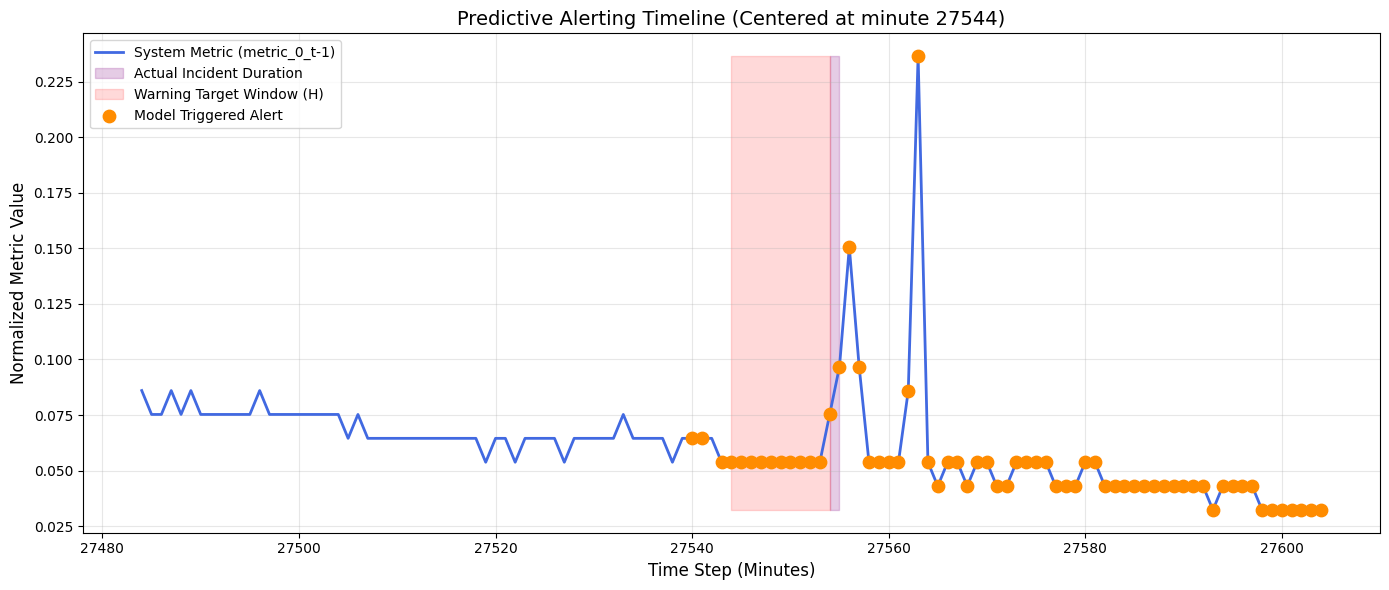

In [21]:
plot_incident_timeline(X_test_eng, y_test, y_pred_rf_custom, df['is_incident'], metric_name='metric_0_t-1', zoom_index=27544)